This dataset is from https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease

Additional Information

We use 24 + class = 25 ( 11  numeric ,14  nominal)


1.Age(numerical)  	  	age in years

2.Blood Pressure(numerical)	       	bp in mm/Hg

3.Specific Gravity(nominal)	  	sg - (1.005,1.010,1.015,1.020,1.025)

4.Albumin(nominal)		al - (0,1,2,3,4,5)

5.Sugar(nominal)		su - (0,1,2,3,4,5)

6.Red Blood Cells(nominal)	rbc - (normal,abnormal)

7.Pus Cell (nominal)		pc - (normal,abnormal)
 	
8.Pus Cell clumps(nominal)		pcc - (present,notpresent)
 	
9.Bacteria(nominal)		ba  - (present,notpresent)

10.Blood Glucose Random(numerical)				bgr in mgs/dl

11.Blood Urea(numerical)			bu in mgs/dl

12.Serum Creatinine(numerical)			sc in mgs/dl

13.Sodium(numerical)		sod in mEq/L

14.Potassium(numerical)			pot in mEq/L

15.Hemoglobin(numerical)		hemo in gms

16.Packed  Cell Volume(numerical) 	

17.White Blood Cell Count(numerical)		wc in cells/cumm
 	
18.Red Blood Cell Count(numerical)			rc in millions/cmm

19.Hypertension(nominal)			htn - (yes,no)

20.Diabetes Mellitus(nominal)			dm - (yes,no)

21.Coronary Artery Disease(nominal)		cad - (yes,no)

22.Appetite(nominal)			appet - (good,poor)

23.Pedal Edema(nominal)		pe - (yes,no)	

24.Anemia(nominal)		ane - (yes,no)

25.Class (nominal)		class - (ckd,notckd)

In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('kidney_disease.csv')

In [3]:
df.columns

Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

In [4]:
df.columns = [
    'id','age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
    'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
    'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
    'potassium', 'hemoglobin', 'packed_cell_volume', 'white_blood_cell_count',
    'red_blood_cell_count', 'hypertension', 'diabetes_mellitus',
    'coronary_artery_disease', 'appetite', 'pedal_edema', 'anemia', 'class'
]

In [5]:
df.head()

,id,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,class
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       400 non-null    int64  
 1   age                      391 non-null    float64
 2   blood_pressure           388 non-null    float64
 3   specific_gravity         353 non-null    float64
 4   albumin                  354 non-null    float64
 5   sugar                    351 non-null    float64
 6   red_blood_cells          248 non-null    object 
 7   pus_cell                 335 non-null    object 
 8   pus_cell_clumps          396 non-null    object 
 9   bacteria                 396 non-null    object 
 10  blood_glucose_random     356 non-null    float64
 11  blood_urea               381 non-null    float64
 12  serum_creatinine         383 non-null    float64
 13  sodium                   313 non-null    float64
 14  potassium                3

In [7]:
# Calculate the proportion of CKD patients
ckd_proportion = sum(df['class'] == 'ckd')*100 / len(df)
print('Proportion of CKD patients:',sum(df['class'] == 'ckd') ,', ',ckd_proportion,'%')

# Calculate the proportion of non-CKD patients
non_ckd_proportion = sum(df['class'] != 'ckd')*100 / len(df)
print('Proportion of non-CKD patients:',sum(df['class'] != 'ckd'),', ',non_ckd_proportion,'%')

Proportion of CKD patients: 248 ,  62.0 %
Proportion of non-CKD patients: 152 ,  38.0 %


In [8]:
# Convert numerical columns to numeric data type
numeric_cols = [
    'age', 'blood_pressure','specific_gravity', 'albumin','sugar', 'blood_glucose_random', 'blood_urea',
    'serum_creatinine', 'sodium', 'potassium', 'hemoglobin',
    'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count'
]

In [9]:
def str_col(df, numeric_cols):
    lst = []
    for var in df.columns:
        if var not in numeric_cols:
            lst.append(var)
    return lst

In [10]:
string_cols = str_col(df, numeric_cols)[1:]

In [11]:
_ = [print(col, df[col].unique()) for col in df]

id [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245

In [12]:
#replace abnormal values
replace_t = {'\t':np.nan,'\t?':np.nan,'\t43':'43','\t6200':'6200','\t8400':'8400',' yes':'yes','\tyes':'yes','\tno':'no','ckd\t':'ckd'}
_ = [print(col, df.replace(replace_t)[col].unique()) for col in df.replace(replace_t)]

id [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245

In [13]:
#drop id columns because it is not essential.
df.drop('id',axis=1,inplace=True)

In [14]:
df = df.replace(replace_t)

In [15]:
_ = [print(col, df[col].unique()) for col in df]

age [48.  7. 62. 51. 60. 68. 24. 52. 53. 50. 63. 40. 47. 61. 21. 42. 75. 69.
 nan 73. 70. 65. 76. 72. 82. 46. 45. 35. 54. 11. 59. 67. 15. 55. 44. 26.
 64. 56.  5. 74. 38. 58. 71. 34. 17. 12. 43. 41. 57.  8. 39. 66. 81. 14.
 27. 83. 30.  4.  3.  6. 32. 80. 49. 90. 78. 19.  2. 33. 36. 37. 23. 25.
 20. 29. 28. 22. 79.]
blood_pressure [ 80.  50.  70.  90.  nan 100.  60. 110. 140. 180. 120.]
specific_gravity [1.02  1.01  1.005 1.015   nan 1.025]
albumin [ 1.  4.  2.  3.  0. nan  5.]
sugar [ 0.  3.  4.  1. nan  2.  5.]
red_blood_cells [nan 'normal' 'abnormal']
pus_cell ['normal' 'abnormal' nan]
pus_cell_clumps ['notpresent' 'present' nan]
bacteria ['notpresent' 'present' nan]
blood_glucose_random [121.  nan 423. 117. 106.  74. 100. 410. 138.  70. 490. 380. 208.  98.
 157.  76.  99. 114. 263. 173.  95. 108. 156. 264. 123.  93. 107. 159.
 140. 171. 270.  92. 137. 204.  79. 207. 124. 144.  91. 162. 246. 253.
 141. 182.  86. 150. 146. 425. 112. 250. 360. 163. 129. 133. 102. 158.
 165. 132. 104. 

In [16]:
df[numeric_cols].head()

,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,hemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2
1,7.0,50.0,1.020,4.0,0.0,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN
2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6


In [17]:
df[string_cols].head()

,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,class
0,NaN,normal,notpresent,notpresent,yes,yes,no,good,no,no,ckd
1,NaN,normal,notpresent,notpresent,no,no,no,good,no,no,ckd
2,normal,normal,notpresent,notpresent,no,yes,no,poor,no,yes,ckd
3,normal,abnormal,present,notpresent,yes,no,no,poor,yes,yes,ckd
4,normal,normal,notpresent,notpresent,no,no,no,good,no,no,ckd


In [18]:
cat = {'normal':1,'abnormal':0,'present':1,'notpresent':0,'yes':1,'no':0,'good':1,'poor':0,'ckd':1,'notckd':0}

In [19]:
df = df.applymap(lambda x: cat.get(x, x))

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    float64
 6   pus_cell                 335 non-null    float64
 7   pus_cell_clumps          396 non-null    float64
 8   bacteria                 396 non-null    float64
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  hemoglobin               3

In [21]:
#change cell type object to float
for column in df:
    if df[column].dtype == object:
        df[column] = df[column].astype(float)

#### Imputation missing data

In [22]:
df.isnull().sum()

age                          9
blood_pressure              12
specific_gravity            47
albumin                     46
sugar                       49
red_blood_cells            152
pus_cell                    65
pus_cell_clumps              4
bacteria                     4
blood_glucose_random        44
blood_urea                  19
serum_creatinine            17
sodium                      87
potassium                   88
hemoglobin                  52
packed_cell_volume          71
white_blood_cell_count     106
red_blood_cell_count       131
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
pedal_edema                  1
anemia                       1
class                        0
dtype: int64

In [23]:
from sklearn.impute import SimpleImputer

impute = SimpleImputer(missing_values=np.nan, strategy= 'mean')

In [24]:
df_impute=pd.DataFrame(impute.fit_transform(df))

In [25]:
df_impute.columns = df.columns

In [26]:
df_impute.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      400 non-null    float64
 1   blood_pressure           400 non-null    float64
 2   specific_gravity         400 non-null    float64
 3   albumin                  400 non-null    float64
 4   sugar                    400 non-null    float64
 5   red_blood_cells          400 non-null    float64
 6   pus_cell                 400 non-null    float64
 7   pus_cell_clumps          400 non-null    float64
 8   bacteria                 400 non-null    float64
 9   blood_glucose_random     400 non-null    float64
 10  blood_urea               400 non-null    float64
 11  serum_creatinine         400 non-null    float64
 12  sodium                   400 non-null    float64
 13  potassium                400 non-null    float64
 14  hemoglobin               4

In [91]:
df = df_impute.copy()

#### Data Visualization

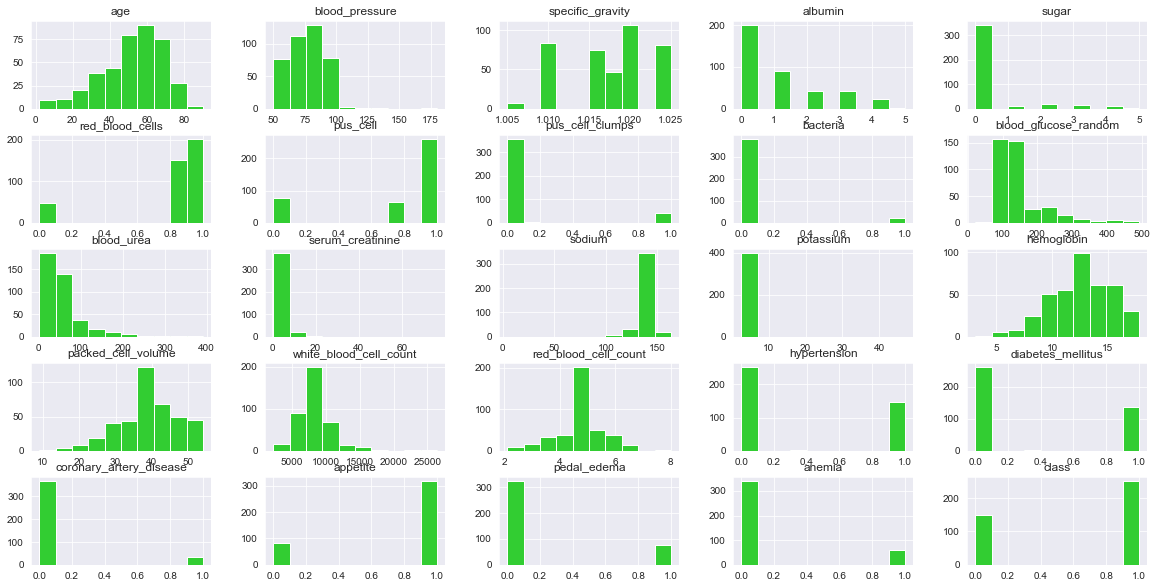

In [93]:
import matplotlib.pyplot as plt

#Find the distribution of features
#Create a histogram
df.hist(figsize=(20,10),color='limegreen')
#Save the plot
_=plt.savefig('image1.jpg')
# Display the plot
plt.show()

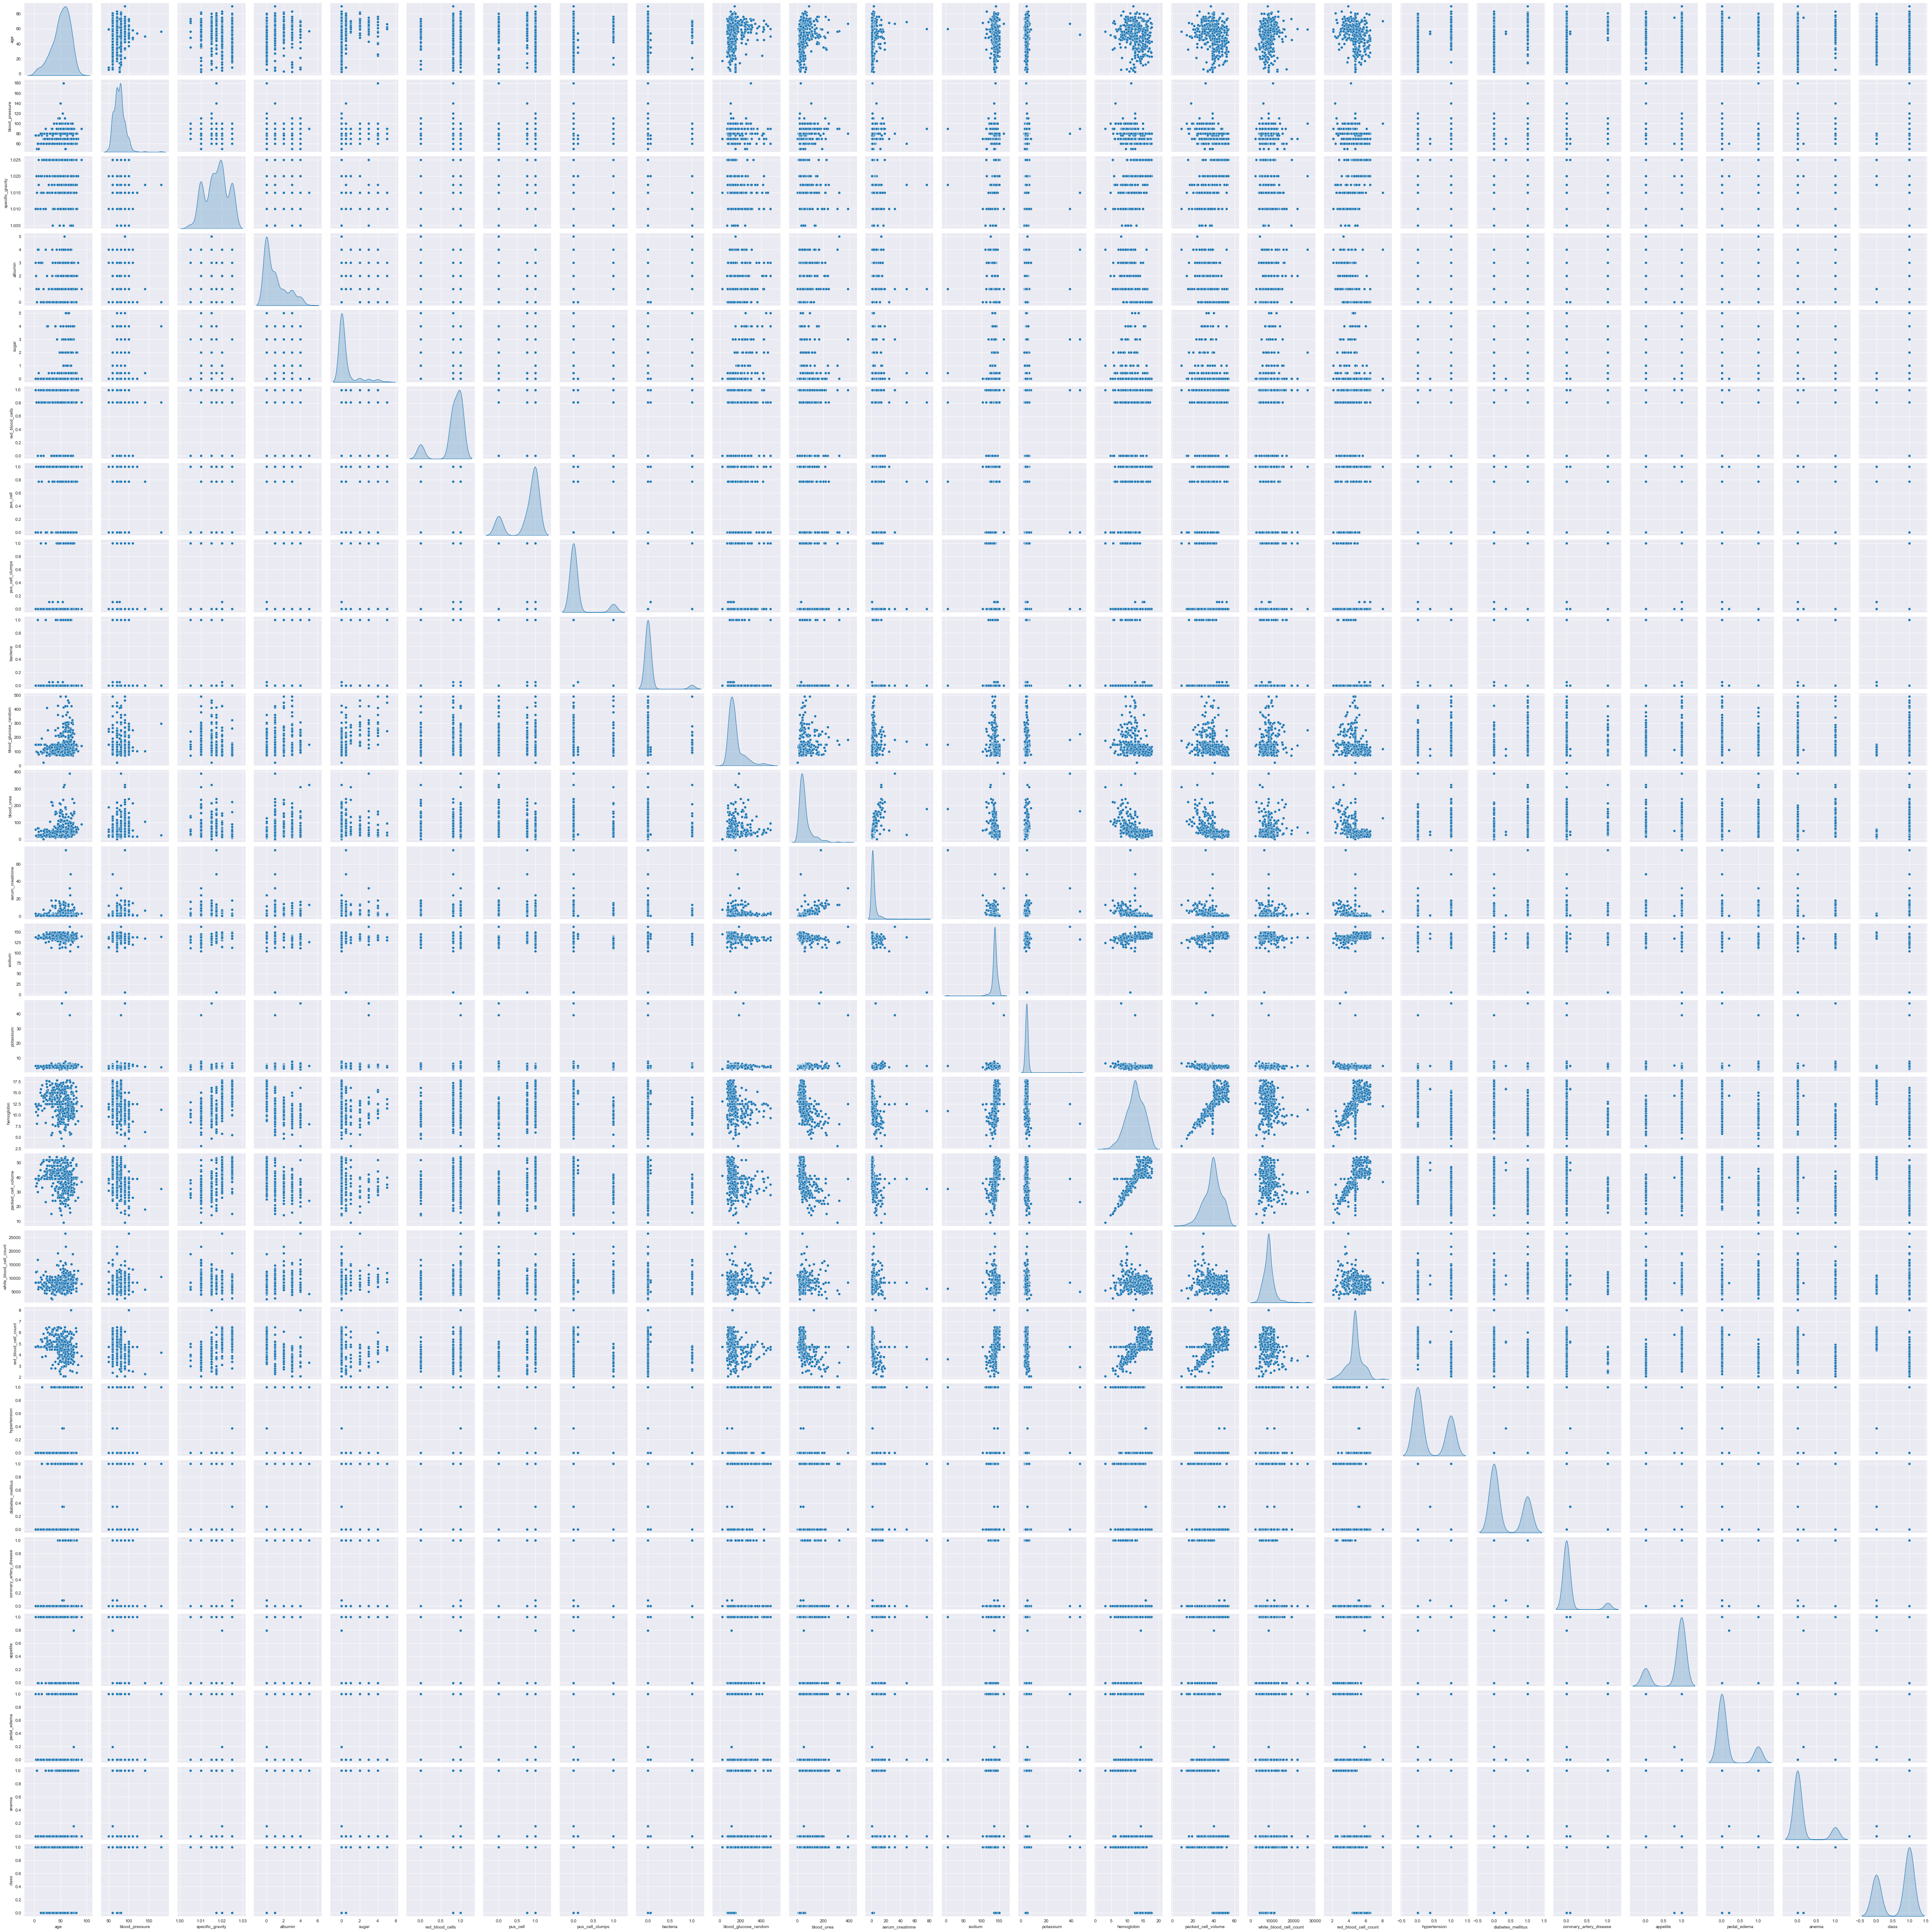

In [94]:
# Create a pairwise scatter plot matrix
import seaborn as sns
sns.pairplot(df.dropna(), diag_kind='kde')
plt.show()

In [95]:
# Calculate correlation matrix
correlation_matrix = df.corr()
correlation_matrix['class'].sort_values(ascending=False)

class                      1.000000
albumin                    0.599238
hypertension               0.586349
diabetes_mellitus          0.555104
blood_glucose_random       0.401374
pedal_edema                0.373697
blood_urea                 0.372033
sugar                      0.327812
anemia                     0.324108
serum_creatinine           0.294079
blood_pressure             0.290600
pus_cell_clumps            0.261001
coronary_artery_disease    0.234166
age                        0.225405
white_blood_cell_count     0.205274
bacteria                   0.183779
potassium                  0.076921
sodium                    -0.342288
appetite                  -0.391824
pus_cell                  -0.430991
red_blood_cells           -0.447155
red_blood_cell_count      -0.590913
packed_cell_volume        -0.690060
specific_gravity          -0.698957
hemoglobin                -0.729628
Name: class, dtype: float64

In [96]:
correlation = correlation_matrix['class'].sort_values(ascending=False)

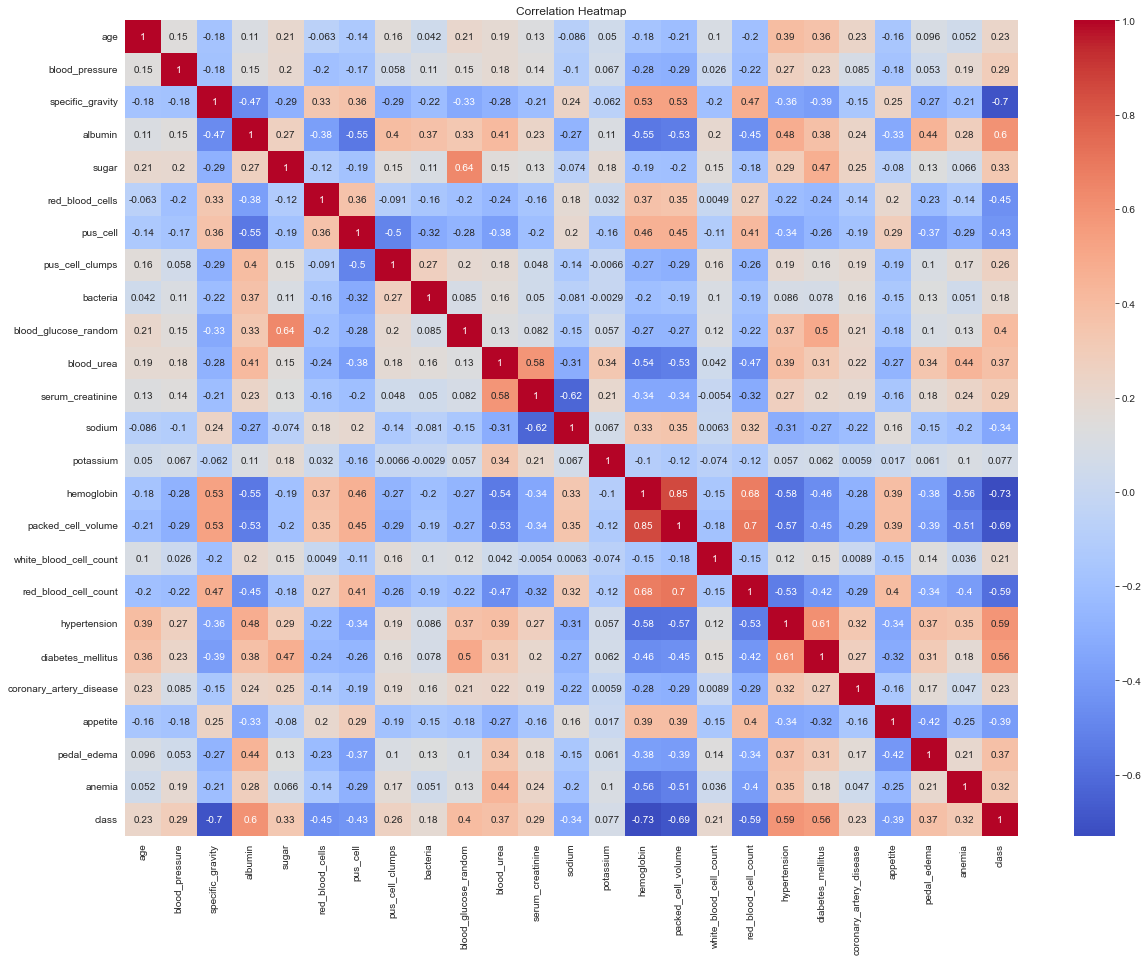

In [97]:
# Create correlation heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [98]:
print([(correlation.index[index], round(attr, 3)) for index, attr in enumerate(correlation) if attr > 0.5 or attr < -0.5])

[('class', 1.0), ('albumin', 0.599), ('hypertension', 0.586), ('diabetes_mellitus', 0.555), ('red_blood_cell_count', -0.591), ('packed_cell_volume', -0.69), ('specific_gravity', -0.699), ('hemoglobin', -0.73)]


In [99]:
cor_index = list((correlation.index[index]) for index, attr in enumerate(correlation) if attr > 0.5 or attr < -0.5)
cor_index[1:]

['albumin',
 'hypertension',
 'diabetes_mellitus',
 'red_blood_cell_count',
 'packed_cell_volume',
 'specific_gravity',
 'hemoglobin']

In [100]:
X_column_corr = cor_index[1:]
X_column_corr

['albumin',
 'hypertension',
 'diabetes_mellitus',
 'red_blood_cell_count',
 'packed_cell_volume',
 'specific_gravity',
 'hemoglobin']

### Split Data in each feature selection method

In [128]:
#Split the original data into features and target
from sklearn.model_selection import train_test_split

X = df.drop('class',axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=10, stratify=y)

In [131]:
#1. Filter selection : Correlation based method
X1 = X[X_column_corr]

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y, test_size=0.3,random_state=10, stratify=y)

### Train model

In [146]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

## Logistic regression

### Model without feature selection technique

In [140]:
from sklearn.linear_model import LogisticRegression
#Train model
LR = LogisticRegression()
LR.fit(X_train,y_train)

C:\Users\Admin\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [144]:
from sklearn import metrics
y_train_pred = LR.predict(X_train)
print(metrics.classification_report(y_train,y_train_pred))

              precision    recall  f1-score   support

         0.0       0.92      0.92      0.92       105
         1.0       0.95      0.95      0.95       175

    accuracy                           0.94       280
   macro avg       0.94      0.94      0.94       280
weighted avg       0.94      0.94      0.94       280



In [143]:
y_test_pred = LR.predict(X_test)
print(metrics.classification_report(y_test,y_test_pred))

              precision    recall  f1-score   support

         0.0       0.89      0.87      0.88        45
         1.0       0.92      0.93      0.93        75

    accuracy                           0.91       120
   macro avg       0.90      0.90      0.90       120
weighted avg       0.91      0.91      0.91       120



### Model with filter technique : Correlation based method

In [148]:
LR.fit(X1_train,y1_train)

LogisticRegression()

In [155]:
y1_train_pred_LR = LR.predict(X1_train)
print(metrics.classification_report(y1_train,y1_train_pred_LR))

              precision    recall  f1-score   support

         0.0       0.95      0.98      0.97       105
         1.0       0.99      0.97      0.98       175

    accuracy                           0.97       280
   macro avg       0.97      0.98      0.97       280
weighted avg       0.98      0.97      0.98       280



In [156]:
y1_test_pred_LR = LR.predict(X1_test)
print(metrics.classification_report(y1_test,y1_test_pred_LR))

              precision    recall  f1-score   support

         0.0       1.00      0.96      0.98        45
         1.0       0.97      1.00      0.99        75

    accuracy                           0.98       120
   macro avg       0.99      0.98      0.98       120
weighted avg       0.98      0.98      0.98       120



## Support vector machine

In [175]:
from sklearn.svm import SVC
SVC = SVC()
SVC.fit(X_train,y_train)

SVC()

In [176]:
y_train_pred_svc = SVC.predict(X_train)
print(metrics.classification_report(y_train,y_train_pred_svc))

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       105
         1.0       0.62      1.00      0.77       175

    accuracy                           0.62       280
   macro avg       0.31      0.50      0.38       280
weighted avg       0.39      0.62      0.48       280



C:\Users\Admin\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Admin\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Admin\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [177]:
y_test_pred_svc = SVC.predict(X_test)
print(metrics.classification_report(y_test,y_test_pred_svc))

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        45
         1.0       0.62      1.00      0.77        75

    accuracy                           0.62       120
   macro avg       0.31      0.50      0.38       120
weighted avg       0.39      0.62      0.48       120



C:\Users\Admin\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Admin\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Admin\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [183]:
SVC.fit(X1_train,y1_train)
y1_train_pred_svc = SVC.predict(X1_train)
print(metrics.classification_report(y1_train,y1_train_pred_svc))

              precision    recall  f1-score   support

         0.0       0.90      0.90      0.90       105
         1.0       0.94      0.94      0.94       175

    accuracy                           0.93       280
   macro avg       0.92      0.92      0.92       280
weighted avg       0.92      0.93      0.92       280



In [184]:
y1_test_pred_svc = SVC.predict(X1_test)
print(metrics.classification_report(y1_test,y1_test_pred_svc))

              precision    recall  f1-score   support

         0.0       0.93      0.87      0.90        45
         1.0       0.92      0.96      0.94        75

    accuracy                           0.93       120
   macro avg       0.93      0.91      0.92       120
weighted avg       0.93      0.93      0.92       120



## Naive's Baye

In [185]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train,y_train)

GaussianNB()

In [186]:
y_train_pred_nb = nb.predict(X_train)
print(metrics.classification_report(y_train,y_train_pred_nb))

              precision    recall  f1-score   support

         0.0       0.88      1.00      0.94       105
         1.0       1.00      0.92      0.96       175

    accuracy                           0.95       280
   macro avg       0.94      0.96      0.95       280
weighted avg       0.96      0.95      0.95       280



In [187]:
y_test_pred_nb = nb.predict(X_test)
print(metrics.classification_report(y_test,y_test_pred_nb))

              precision    recall  f1-score   support

         0.0       0.96      1.00      0.98        45
         1.0       1.00      0.97      0.99        75

    accuracy                           0.98       120
   macro avg       0.98      0.99      0.98       120
weighted avg       0.98      0.98      0.98       120



In [189]:
nb.fit(X1_train,y1_train)
y1_train_pred_nb = nb.predict(X1_train)
print(metrics.classification_report(y1_train,y1_train_pred_nb))

              precision    recall  f1-score   support

         0.0       0.92      0.95      0.93       105
         1.0       0.97      0.95      0.96       175

    accuracy                           0.95       280
   macro avg       0.94      0.95      0.95       280
weighted avg       0.95      0.95      0.95       280



In [192]:
y1_test_pred_nb = nb.predict(X1_test)
print(metrics.classification_report(y_test,y1_test_pred_nb))

              precision    recall  f1-score   support

         0.0       0.96      0.96      0.96        45
         1.0       0.97      0.97      0.97        75

    accuracy                           0.97       120
   macro avg       0.96      0.96      0.96       120
weighted avg       0.97      0.97      0.97       120



## KNN

In [193]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

In [198]:
knn.fit(X_train,y_train)
y_train_pred_knn = knn.predict(X_train)
print(metrics.classification_report(y_train,y_train_pred_knn))

              precision    recall  f1-score   support

         0.0       0.71      0.92      0.80       105
         1.0       0.94      0.77      0.85       175

    accuracy                           0.83       280
   macro avg       0.83      0.85      0.83       280
weighted avg       0.86      0.83      0.83       280



In [199]:
y_test_pred_knn = knn.predict(X_test)
print(metrics.classification_report(y_test,y_test_pred_knn))

              precision    recall  f1-score   support

         0.0       0.60      0.76      0.67        45
         1.0       0.83      0.69      0.75        75

    accuracy                           0.72       120
   macro avg       0.71      0.72      0.71       120
weighted avg       0.74      0.72      0.72       120



In [205]:
knn.fit(X1_train,y1_train)
y1_train_pred_knn = knn.predict(X1_train)
print(metrics.classification_report(y1_train,y1_train_pred_knn))

              precision    recall  f1-score   support

         0.0       0.90      0.99      0.95       105
         1.0       0.99      0.94      0.96       175

    accuracy                           0.96       280
   macro avg       0.95      0.96      0.96       280
weighted avg       0.96      0.96      0.96       280



In [206]:
y1_test_pred_knn = knn.predict(X1_test)
print(metrics.classification_report(y_test,y1_test_pred_knn))

              precision    recall  f1-score   support

         0.0       0.89      0.93      0.91        45
         1.0       0.96      0.93      0.95        75

    accuracy                           0.93       120
   macro avg       0.93      0.93      0.93       120
weighted avg       0.93      0.93      0.93       120

